In [ ]:
# ---------------------------------------------
# Financial Forecasting Pipeline for Fauji Fertilizer Co. (FFC)
# Developed by: Muniza Bashir | Seat No: B21120206035
# Supervisor: Sir Daniyal Hussain
# ---------------------------------------------

# Install necessary packages
!pip install yfinance pandas numpy scikit-learn matplotlib seaborn statsmodels scipy

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

from scipy.stats import norm



In [ ]:
# Download stock data
stock_data = yf.download('FFC', start='2018-01-01', end='2023-01-01')
stock_data = stock_data.dropna()
stock_data['Log_Returns'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))
stock_data['SMA_30'] = stock_data['Close'].rolling(window=30).mean()
stock_data['Volatility'] = stock_data['Log_Returns'].rolling(window=30).std()
stock_data = stock_data.dropna()

# Show data
stock_data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log_Returns,SMA_30,Volatility
Ticker,FFC,FFC,FFC,FFC,FFC,,,
Date,,,,,,,,
2018-02-14,11.459706,11.489317,11.430094,11.465629,93400,-0.002065,11.475458,0.008846
2018-02-15,11.465634,11.548547,11.406411,11.471557,189400,0.000517,11.464648,0.008793
2018-02-16,11.453791,11.459713,11.412335,11.436023,127400,-0.001034,11.451286,0.008709
2018-02-20,11.444257,11.474045,11.402555,11.402555,73600,-0.000833,11.437605,0.008707
2018-02-21,11.497875,11.593194,11.426386,11.426386,147600,0.004674,11.426104,0.008772


In [ ]:
# Create synthetic Credit Risk Data
np.random.seed(42)
n_samples = 1000
credit_data = pd.DataFrame({
    'credit_score': np.random.normal(700, 50, n_samples),
    'income': np.random.normal(50000, 15000, n_samples),
    'loan_amount': np.random.normal(15000, 5000, n_samples),
    'default': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15])
})

credit_data.head()


,credit_score,income,loan_amount,default
0,724.835708,70990.331549,11624.108625,0
1,693.086785,63869.505244,14277.406646,1
2,732.384427,50894.455549,11037.900395,0
3,776.151493,40295.948334,13460.192352,1
4,688.292331,60473.349704,5531.926665,0


In [ ]:
# Create synthetic Revenue/Expense Data
np.random.seed(42)
dates = pd.date_range(start='2018-01-01', periods=60, freq='M')
revenue_data = pd.DataFrame({
    'Date': dates,
    'Revenue': 50000 + np.random.normal(0, 5000, size=60).cumsum(),
    'Expenses': 30000 + np.random.normal(0, 3000, size=60).cumsum()
})

revenue_data['Profit'] = revenue_data['Revenue'] - revenue_data['Expenses']
revenue_data.head()


<ipython-input-6-54d768a2e3eb>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2018-01-01', periods=60, freq='M')


,Date,Revenue,Expenses,Profit
0,2018-01-31,52483.570765,28562.477286,23921.093479
1,2018-02-28,51792.249259,28005.500356,23786.748903
2,2018-03-31,55030.691950,24686.495434,30344.196515
3,2018-04-30,62645.841232,21097.875562,41547.965670
4,2018-05-31,61475.074358,23535.453029,37939.621329


from matplotlib import pyplot as plt
_df_0['Revenue'].plot(kind='hist', bins=20, title='Revenue')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Expenses'].plot(kind='hist', bins=20, title='Expenses')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Profit'].plot(kind='hist', bins=20, title='Profit')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Profit']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Profit')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Date'}, axis=1)
              .sort_values('Date', ascending=True))
  xs = counted['Date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_9['Revenue'].plot(kind='line', figsize=(8, 4), title='Revenue')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['Expenses'].plot(kind='line', figsize=(8, 4), title='Expenses')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['Profit'].plot(kind='line', figsize=(8, 4), title='Profit')
plt.gca().spines[['top', 'right']].set_visible(False)

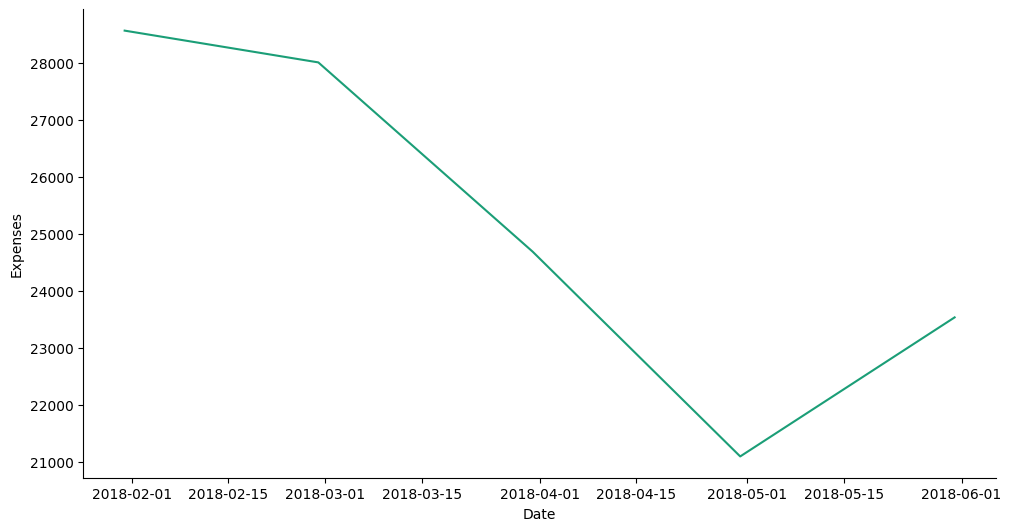

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Expenses']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_6.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Expenses')

Linear Regression:
RMSE: 0.5371103494565133
MAE: 0.3539754161137575
R²: 0.9363571890060678


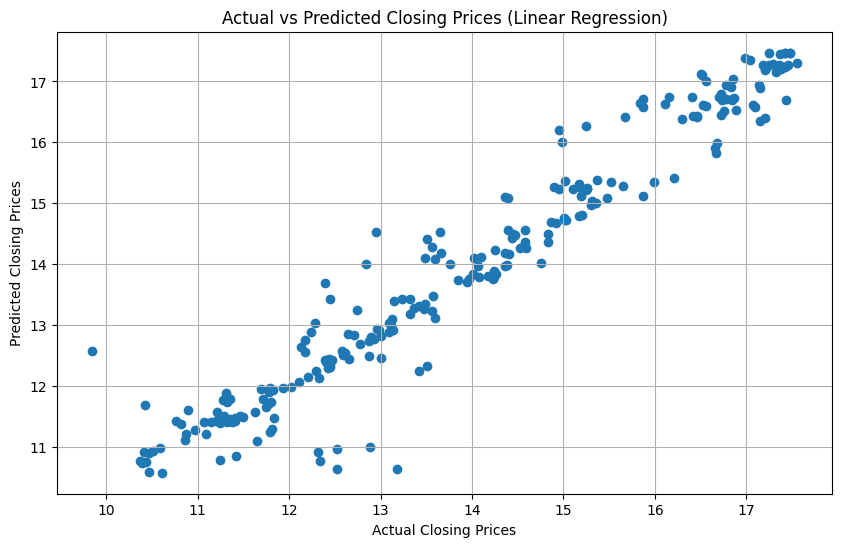

In [ ]:
# Features and Target
X = stock_data[['SMA_30', 'Volatility']]
y = stock_data['Close']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Linear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

# Plot
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel('Actual Closing Prices')
plt.ylabel('Predicted Closing Prices')
plt.title('Actual vs Predicted Closing Prices (Linear Regression)')
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

ARIMA Model:
RMSE: 2.8116882730572224
MAE: 2.5540617494793576
R²: -4.595486988837684


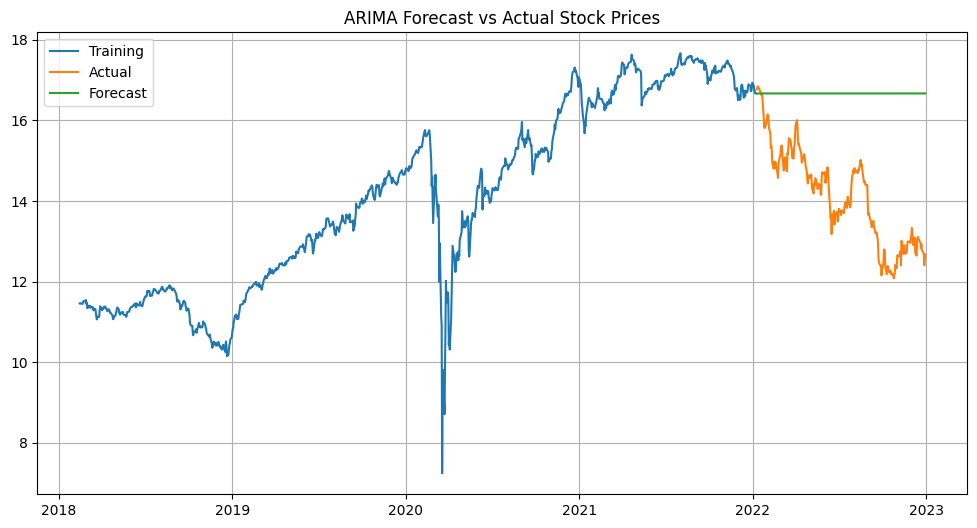

In [ ]:
# ARIMA model needs only one series (we'll use 'Close')
train_size = int(len(stock_data) * 0.8)
train, test = stock_data['Close'][:train_size], stock_data['Close'][train_size:]

# Fit ARIMA
arima_model = ARIMA(train, order=(5,1,0))
arima_result = arima_model.fit()

# Forecast
arima_forecast = arima_result.forecast(steps=len(test))

# Evaluation
print("ARIMA Model:")
print("RMSE:", np.sqrt(mean_squared_error(test, arima_forecast)))
print("MAE:", mean_absolute_error(test, arima_forecast))
print("R²:", r2_score(test, arima_forecast))

# Plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_forecast, label='Forecast')
plt.legend()
plt.title('ARIMA Forecast vs Actual Stock Prices')
plt.grid(True)
plt.show()


In [ ]:
# Features and Target for Credit Risk
X_credit = credit_data[['credit_score', 'income', 'loan_amount']]
y_credit = credit_data['default']

# Train-Test Split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_credit, y_credit, test_size=0.2, random_state=42)

# Logistic Regression
logreg_model = LogisticRegression()
logreg_model.fit(Xc_train, yc_train)

# Predictions using a lower probability threshold (e.g., 0.3)
yc_pred_logreg_proba = logreg_model.predict_proba(Xc_test)[:, 1]  # Get probabilities for class 1
yc_pred_logreg = (yc_pred_logreg_proba >= 0.3).astype(int)       # Apply threshold

# Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(Xc_train, yc_train)
yc_pred_tree = tree_model.predict(Xc_test)  # Using default threshold for Decision Tree

# Evaluation Function (with zero_division handling)
def evaluate_classification(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))  # Handle zero division
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))      # Handle zero division
    print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))          # Handle zero division
    print("\n")

# Evaluate both models
evaluate_classification(yc_test, yc_pred_logreg, "Logistic Regression")
evaluate_classification(yc_test, yc_pred_tree, "Decision Tree Classifier")


--- Logistic Regression ---
Accuracy: 0.865
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


--- Decision Tree Classifier ---
Accuracy: 0.85
Precision: 0.0
Recall: 0.0
F1 Score: 0.0




Revenue Forecasting:
RMSE: 8623.359103500814
MAE: 6765.603038483262
R²: 0.9068358390167899


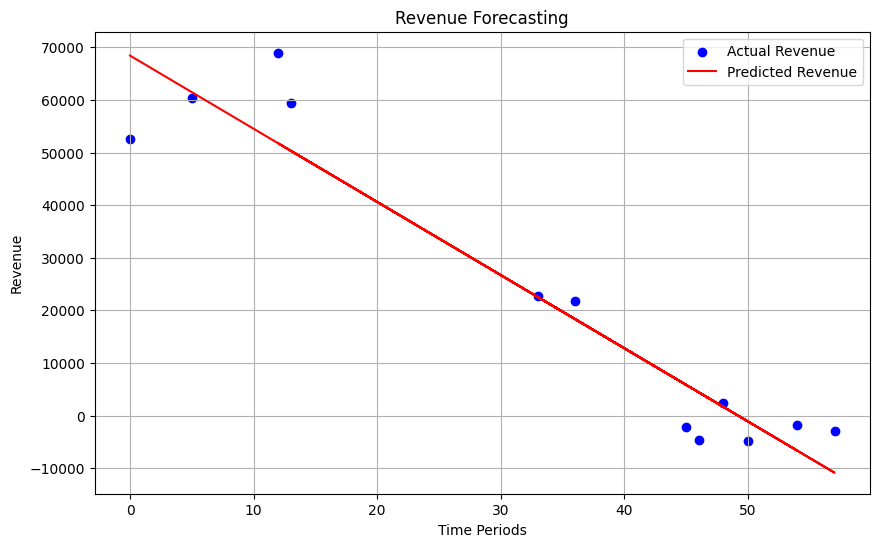

In [ ]:
# Revenue Forecasting
X_rev = np.arange(len(revenue_data)).reshape(-1,1)
y_rev = revenue_data['Revenue']

# Split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_rev, y_rev, test_size=0.2, random_state=42)

# Regression Model
rev_model = LinearRegression()
rev_model.fit(Xr_train, yr_train)

# Predictions
yr_pred = rev_model.predict(Xr_test)

# Evaluation
print("Revenue Forecasting:")
print("RMSE:", np.sqrt(mean_squared_error(yr_test, yr_pred)))
print("MAE:", mean_absolute_error(yr_test, yr_pred))
print("R²:", r2_score(yr_test, yr_pred))

# Plot
plt.figure(figsize=(10,6))
plt.scatter(Xr_test, yr_test, color='blue', label='Actual Revenue')
plt.plot(Xr_test, yr_pred, color='red', label='Predicted Revenue')
plt.legend()
plt.title('Revenue Forecasting')
plt.xlabel('Time Periods')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


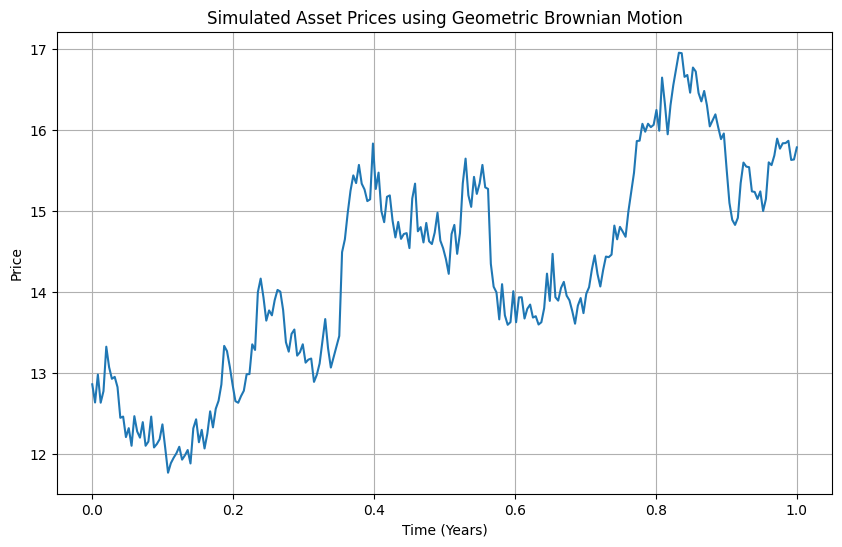

In [ ]:
# Correct GBM Simulation
def simulate_gbm(S0, mu, sigma, T, dt=1/252):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)  # Brownian motion
    X = (mu - 0.5 * sigma**2) * t + sigma * W
    S = S0 * np.exp(X)
    return t, S

# FIX S0 to float (not Series!) - Use .iloc[0] to extract the value
S0 = stock_data['Close'].iloc[-1]  # Last close price as float
# Convert S0 to a float using .iloc[0] to avoid the FutureWarning
S0 = float(S0.iloc[0]) if hasattr(S0, 'iloc') else float(S0)
mu = stock_data['Log_Returns'].mean() * 252
sigma = stock_data['Log_Returns'].std() * np.sqrt(252)
T = 1  # 1 year

# Simulate GBM
t, S = simulate_gbm(S0, mu, sigma, T)

# Plot
plt.figure(figsize=(10,6))
plt.plot(t, S)
plt.title('Simulated Asset Prices using Geometric Brownian Motion')
plt.xlabel('Time (Years)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [ ]:
# Correct Binomial Tree Call Option Pricing
def binomial_tree_call_price(S, K, T, r, sigma, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    # Asset prices at maturity
    ST = np.array([S * (u**j) * (d**(N - j)) for j in range(N + 1)])

    # Option values at maturity
    option = np.maximum(ST - K, 0)

    # Step backwards
    for i in range(N-1, -1, -1):
        option = np.exp(-r*dt) * (p*option[1:i+2] + (1-p)*option[0:i+1])

    # Debugging print statements
    print("Final Option Values:", option)
    print("Discount Factor:", np.exp(-r * dt))
    print("Up Factor (u):", u)
    print("Down Factor (d):", d)
    print("Probability (p):", p)

    return option[0]  # ONLY option[0]

# Parameters
K = 15  # Strike price
r = 0.03  # Risk-free rate
N = 50    # Number of steps
T = 1     # Time to maturity (1 year)

# Correct Extraction of S0
S0_value = stock_data['Close'].iloc[-1]
if hasattr(S0_value, 'values'):
    S0_value = S0_value.values[0]

# Calculate
binomial_price = binomial_tree_call_price(S0_value, K, T, r, sigma, N)

print("S0:", S0_value)
print(f"Binomial Tree Call Option Price: {binomial_price:.2f}")


Final Option Values: [0.86932835]
Discount Factor: 0.9994001799640054
Up Factor (u): 1.0441771121940122
Down Factor (d): 0.9576919359004261
Probability (p): 0.4961340888052443
S0: 12.667119026184082
Binomial Tree Call Option Price: 0.87


In [ ]:
# Black-Scholes Call Option Pricing
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call

# Calculate
# Use S0_value directly as it's already a float
bs_price = black_scholes_call(S0_value, K, T, r, sigma)
print(f"Black-Scholes Call Option Price: {bs_price:.2f}")

Black-Scholes Call Option Price: 0.88


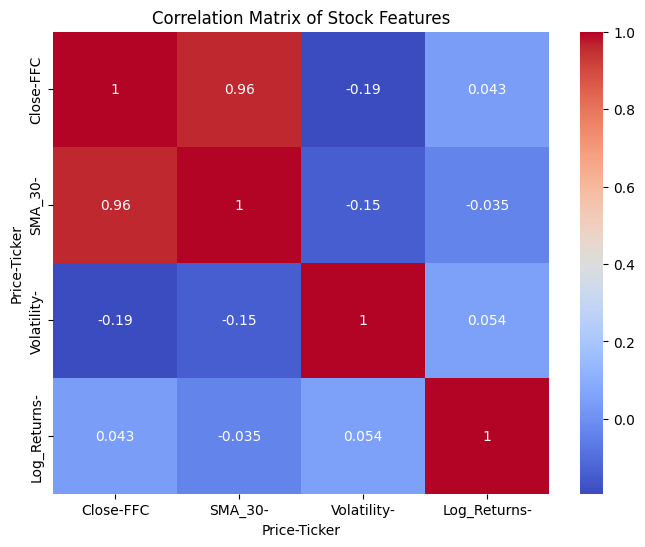

In [ ]:
# EDA: Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(stock_data[['Close', 'SMA_30', 'Volatility', 'Log_Returns']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Stock Features')
plt.show()



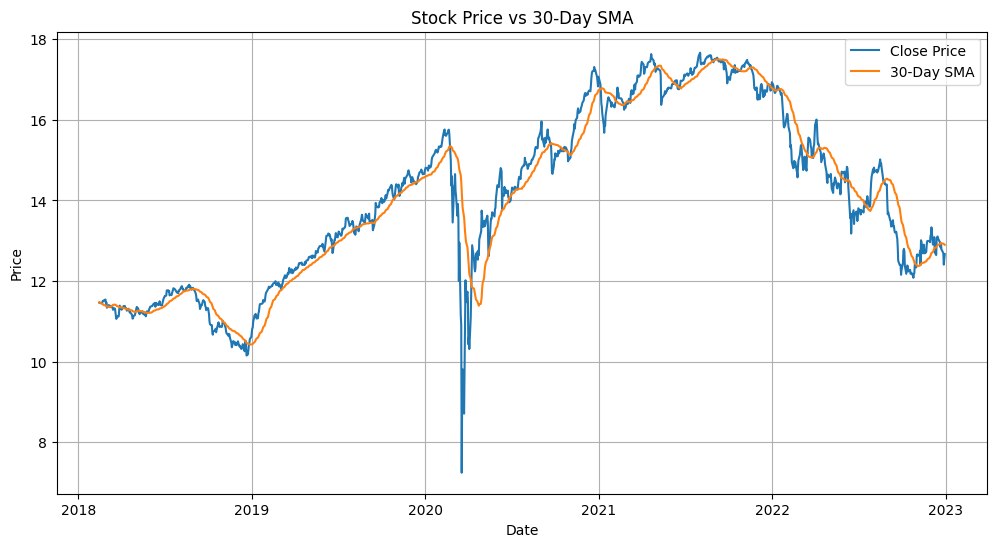

In [ ]:
# Trend over Time
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price')
plt.plot(stock_data.index, stock_data['SMA_30'], label='30-Day SMA')
plt.legend()
plt.title('Stock Price vs 30-Day SMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


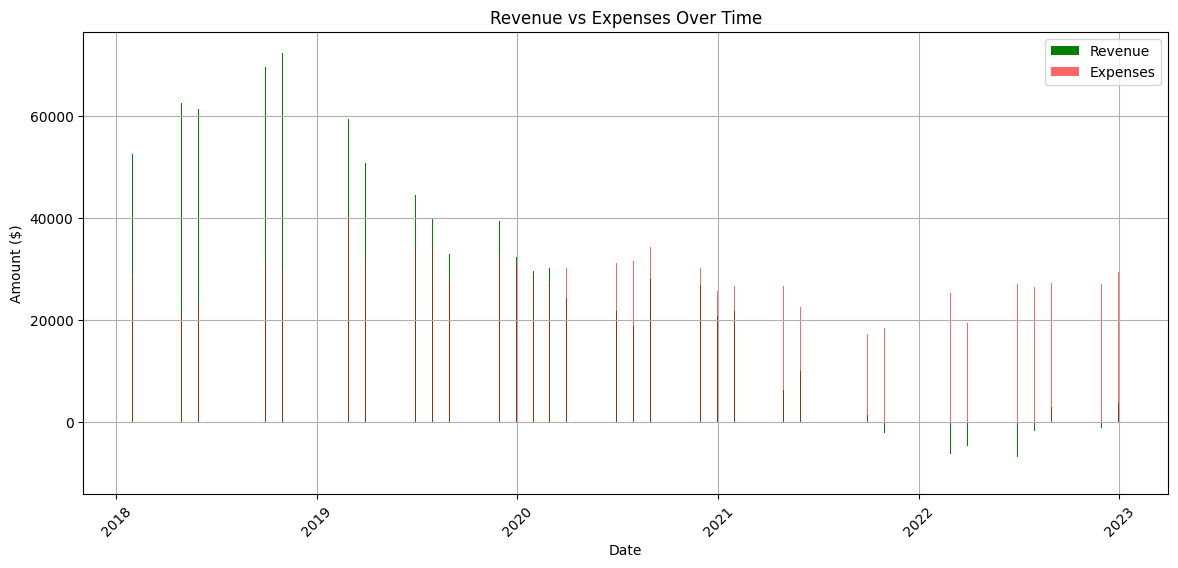

In [ ]:
# Revenue and Expenses Bar Plot
plt.figure(figsize=(14,6))
plt.bar(revenue_data['Date'], revenue_data['Revenue'], label='Revenue', color='green')
plt.bar(revenue_data['Date'], revenue_data['Expenses'], label='Expenses', color='red', alpha=0.6)
plt.title('Revenue vs Expenses Over Time')
plt.xlabel('Date')
plt.ylabel('Amount ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


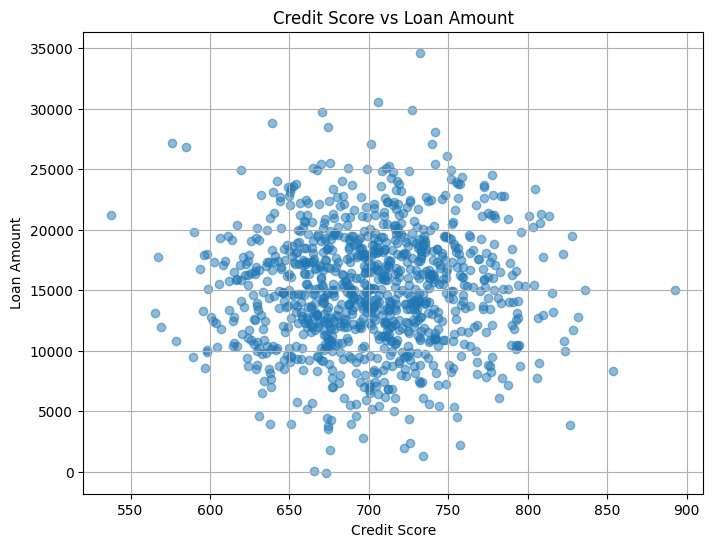

In [ ]:
# Scatter Plot: Credit Score vs Loan Amount
plt.figure(figsize=(8,6))
plt.scatter(credit_data['credit_score'], credit_data['loan_amount'], alpha=0.5)
plt.title('Credit Score vs Loan Amount')
plt.xlabel('Credit Score')
plt.ylabel('Loan Amount')
plt.grid(True)
plt.show()
